In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [7]:
img1 = cv2.imread("raw_captures/objects.jpeg")

img2 = cv2.imread("raw_captures/objects_angle.jpeg")

In [8]:
rgb1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

rgb2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

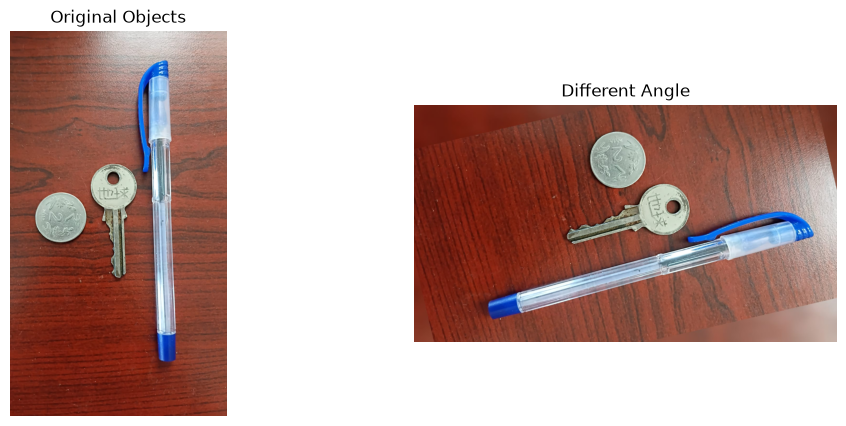

In [9]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(rgb1)
plt.title("Original Objects")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(rgb2)
plt.title("Different Angle")
plt.axis("off")

plt.show()

In [10]:
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)

gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

In [11]:
orb = cv2.ORB_create(1000)

In [12]:
kp1, des1 = orb.detectAndCompute(gray1, None)

kp2, des2 = orb.detectAndCompute(gray2, None)

In [13]:
print("Image 1 Keypoints:", len(kp1))

print("Image 2 Keypoints:", len(kp2))

Image 1 Keypoints: 1000
Image 2 Keypoints: 1000


In [14]:
key1 = cv2.drawKeypoints(
    img1,
    kp1,
    None,
    color=(0,255,0)
)

key2 = cv2.drawKeypoints(
    img2,
    kp2,
    None,
    color=(0,255,0)
)

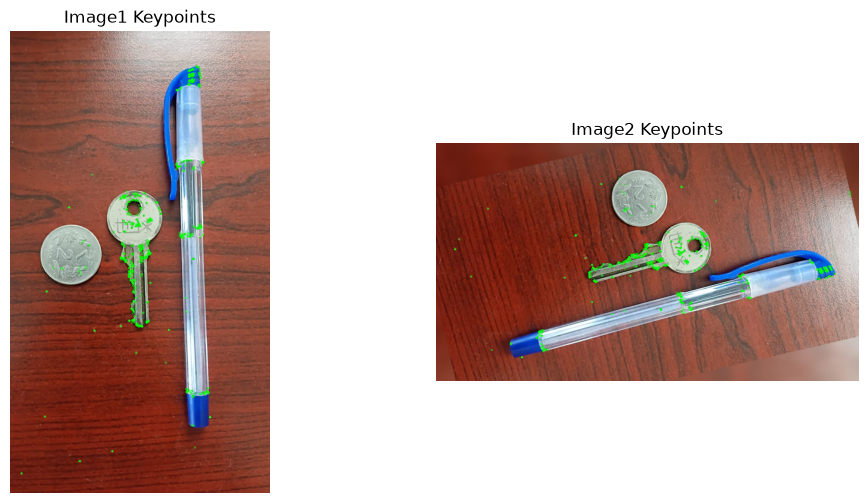

In [15]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(key1,cv2.COLOR_BGR2RGB))
plt.title("Image1 Keypoints")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(key2,cv2.COLOR_BGR2RGB))
plt.title("Image2 Keypoints")
plt.axis("off")

plt.show()

In [16]:
bf = cv2.BFMatcher(cv2.NORM_HAMMING)

In [17]:
matches = bf.match(des1, des2)

In [18]:
matches = sorted(matches, key=lambda x: x.distance)

In [19]:
good_matches = matches[:50]

In [20]:
print("Good Matches:", len(good_matches))

Good Matches: 50


In [21]:
matched = cv2.drawMatches(
    img1,
    kp1,
    img2,
    kp2,
    good_matches,
    None,
    flags=2
)

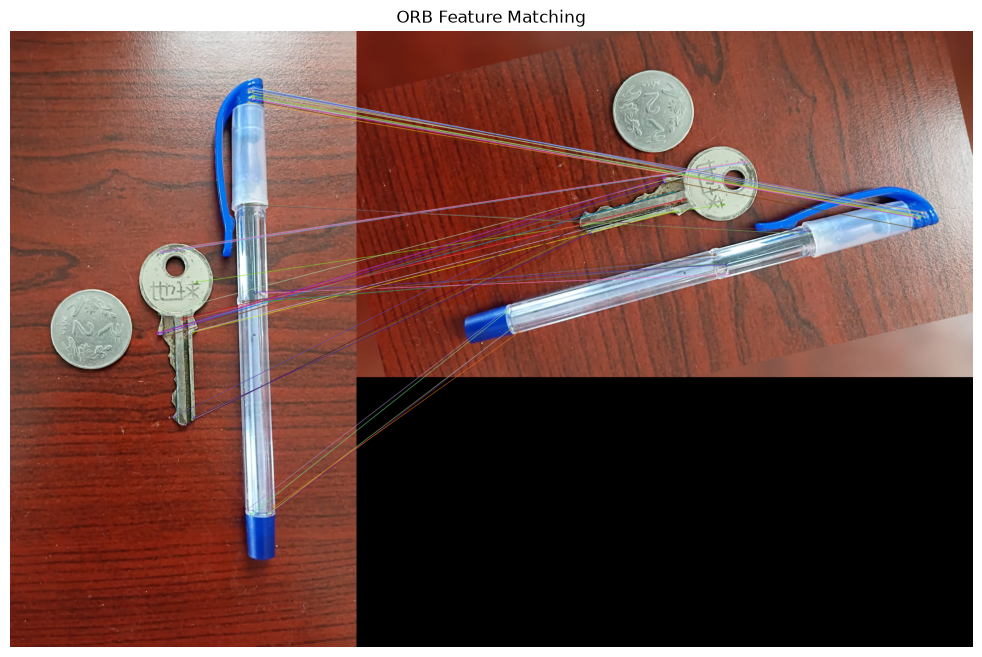

In [22]:
plt.figure(figsize=(18,8))

plt.imshow(cv2.cvtColor(matched,cv2.COLOR_BGR2RGB))

plt.title("ORB Feature Matching")

plt.axis("off")

plt.show()

In [23]:
print("Number of Good Matches:", len(good_matches))

Number of Good Matches: 50


Observation

A second photo of the same desk scene was taken from a different angle.ORB was used to detect keypoints and compute descriptors for both images.A Brute-Force Matcher was used to match the descriptors.
Number of Good Matches:50
The strongest matches were observed on the key and pen because these objects contained more distinctive edges and corner features than the other objects.Even though the camera angle changed, ORB was able to identify many corresponding feature points between the two images.